In [9]:
import h5py

path = "msd_summary_file.h5"   # <-- adjust path if needed

with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print()

    def walk(name, obj):
        if isinstance(obj, h5py.Group):
            print(f"[Group ] {name}")
            for k in obj.keys():
                walk(f"{name}/{k}", obj[k])
        else:
            print(f"[Dataset] {name}  shape={obj.shape}  dtype={obj.dtype}")

    walk("/", f)

Top-level keys: ['analysis', 'metadata', 'musicbrainz']

[Group ] /
[Group ] //analysis
[Dataset] //analysis/songs  shape=(1000000,)  dtype=[('analysis_sample_rate', '<i4'), ('audio_md5', 'S32'), ('danceability', '<f8'), ('duration', '<f8'), ('end_of_fade_in', '<f8'), ('energy', '<f8'), ('idx_bars_confidence', '<i4'), ('idx_bars_start', '<i4'), ('idx_beats_confidence', '<i4'), ('idx_beats_start', '<i4'), ('idx_sections_confidence', '<i4'), ('idx_sections_start', '<i4'), ('idx_segments_confidence', '<i4'), ('idx_segments_loudness_max', '<i4'), ('idx_segments_loudness_max_time', '<i4'), ('idx_segments_loudness_start', '<i4'), ('idx_segments_pitches', '<i4'), ('idx_segments_start', '<i4'), ('idx_segments_timbre', '<i4'), ('idx_tatums_confidence', '<i4'), ('idx_tatums_start', '<i4'), ('key', '<i4'), ('key_confidence', '<f8'), ('loudness', '<f8'), ('mode', '<i4'), ('mode_confidence', '<f8'), ('start_of_fade_out', '<f8'), ('tempo', '<f8'), ('time_signature', '<i4'), ('time_signature_confiden

In [55]:
# -----------------------------
# CONFIG: choose dataset version
# -----------------------------

VERSION = "1000"    # or "50000"

DATA_DIR = f"./out_{VERSION}"

ACOUSTIC_FILE = f"{DATA_DIR}/acoustic_{VERSION}.parquet"
UMAP_FILE     = f"{DATA_DIR}/acoustic_umap_{VERSION}.parquet"
BEHAV_FILE    = f"{DATA_DIR}/behavior_edges_{VERSION}.parquet"
TDA_FILE      = f"{DATA_DIR}/tda_summary_{VERSION}.json"
META_FILE     = "./out_/artist_terms_.parquet"


# ACOUSTIC_FILE = f"out/acoustic.parquet"
# UMAP_FILE     = f"out/acoustic_umap.parquet"
# BEHAV_FILE    = f"out/behavior_edges.parquet"
# TDA_FILE      = f"out/tda_summary.json"

print("Using dataset version:", VERSION)
print("Acoustic:", ACOUSTIC_FILE)
print("UMAP:", UMAP_FILE)
print("Behavior:", BEHAV_FILE)
print("TDA summary:", TDA_FILE)

Using dataset version: 1000
Acoustic: ./out_1000/acoustic_1000.parquet
UMAP: ./out_1000/acoustic_umap_1000.parquet
Behavior: ./out_1000/behavior_edges_1000.parquet
TDA summary: ./out_1000/tda_summary_1000.json


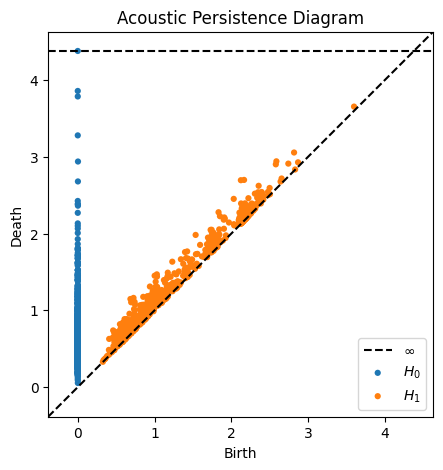

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from persim import plot_diagrams

# Load saved diagrams
dgms = np.load(f"{DATA_DIR}/dgms_ac_{VERSION}.npy", allow_pickle=True)

# IMPORTANT: Convert to a Python list so Persim doesn't choke
dgms = list(dgms)

# Plot
plt.figure(figsize=(5,5))
plot_diagrams(dgms, title="Acoustic Persistence Diagram")
plt.show()

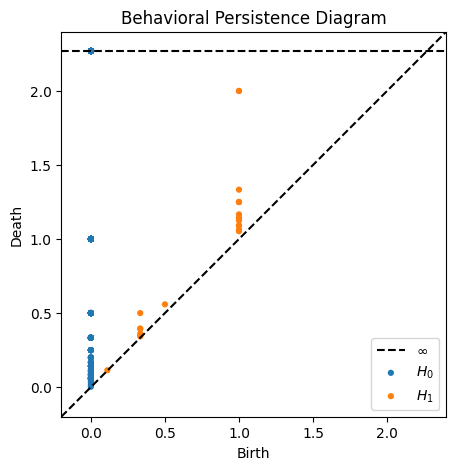

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from persim import plot_diagrams


dgms_be = np.load(f"{DATA_DIR}/dgms_be_{VERSION}.npy", allow_pickle=True)
dgms_be = list(dgms_be)

plt.figure(figsize=(5,5))
plot_diagrams(dgms_be, title="Behavioral Persistence Diagram")
plt.show()

In [75]:
import json

# Load JSON
with open(TDA_FILE, "r") as f:
    tda_summary = json.load(f)

# Pretty print
print("=== TDA Summary ===")
for k, v in tda_summary.items():
    print(f"{k:20s} : {v}")

=== TDA Summary ===
bottleneck_H0        : 1.9294527769088745
bottleneck_H1        : 0.36570847034454346


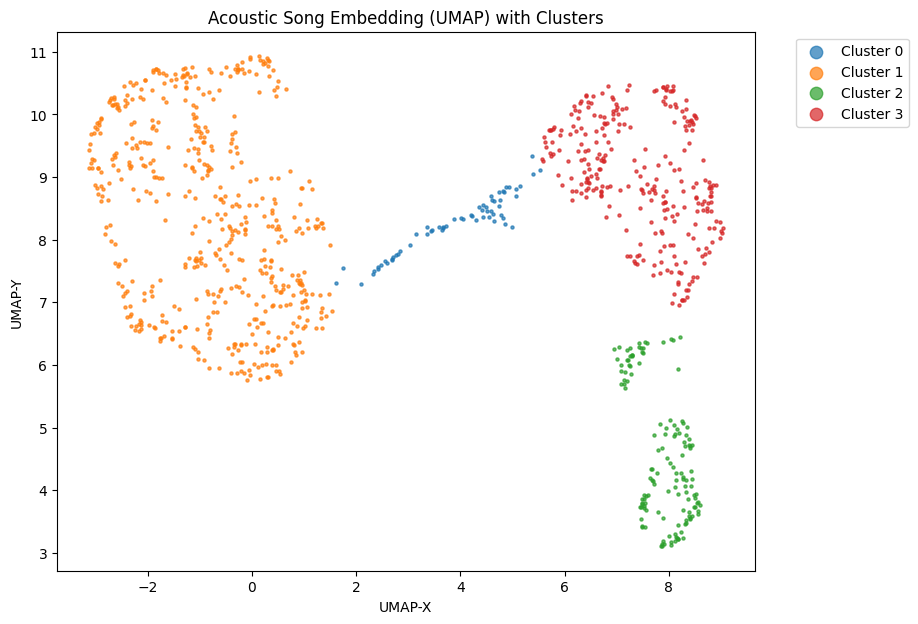

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load UMAP
umap_df = pd.read_parquet(UMAP_FILE)

# Fit KMeans to reveal cluster structure (choose k ~ 8, tweak later)
kmeans = KMeans(n_clusters=4, random_state=42).fit(umap_df[['x', 'y']])
umap_df['cluster'] = kmeans.labels_

# Plot
plt.figure(figsize=(9,7))
for c in sorted(umap_df['cluster'].unique()):
    subset = umap_df[umap_df['cluster'] == c]
    plt.scatter(subset['x'], subset['y'], s=5, alpha=0.7, label=f"Cluster {c}")

plt.title("Acoustic Song Embedding (UMAP) with Clusters")
plt.xlabel("UMAP-X")
plt.ylabel("UMAP-Y")
plt.legend(markerscale=4, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


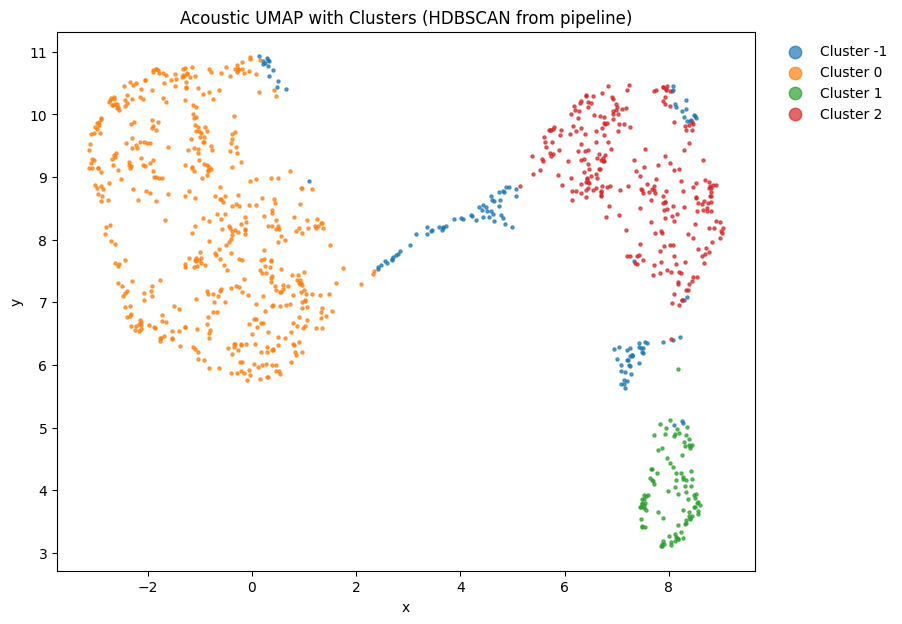

In [77]:
# UMAP clusters (uses existing labels in the file)
import pandas as pd
import matplotlib.pyplot as plt

umap_df = pd.read_parquet(UMAP_FILE)  # has x, y, cluster, song_id

plt.figure(figsize=(9,7))
for c in sorted(umap_df['cluster'].unique()):
    pts = umap_df[umap_df['cluster'] == c]
    plt.scatter(pts['x'], pts['y'], s=5, alpha=0.7, label=f"Cluster {c}")


plt.title("Acoustic UMAP with Clusters (HDBSCAN from pipeline)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(markerscale=4, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()


Edge columns: ['a', 'b', 'w']
[INFO] After pruning (w ≥ 1): 1429 edges
[INFO] Graph nodes: 280, edges: 1429
[INFO] Sparsified edges: 458


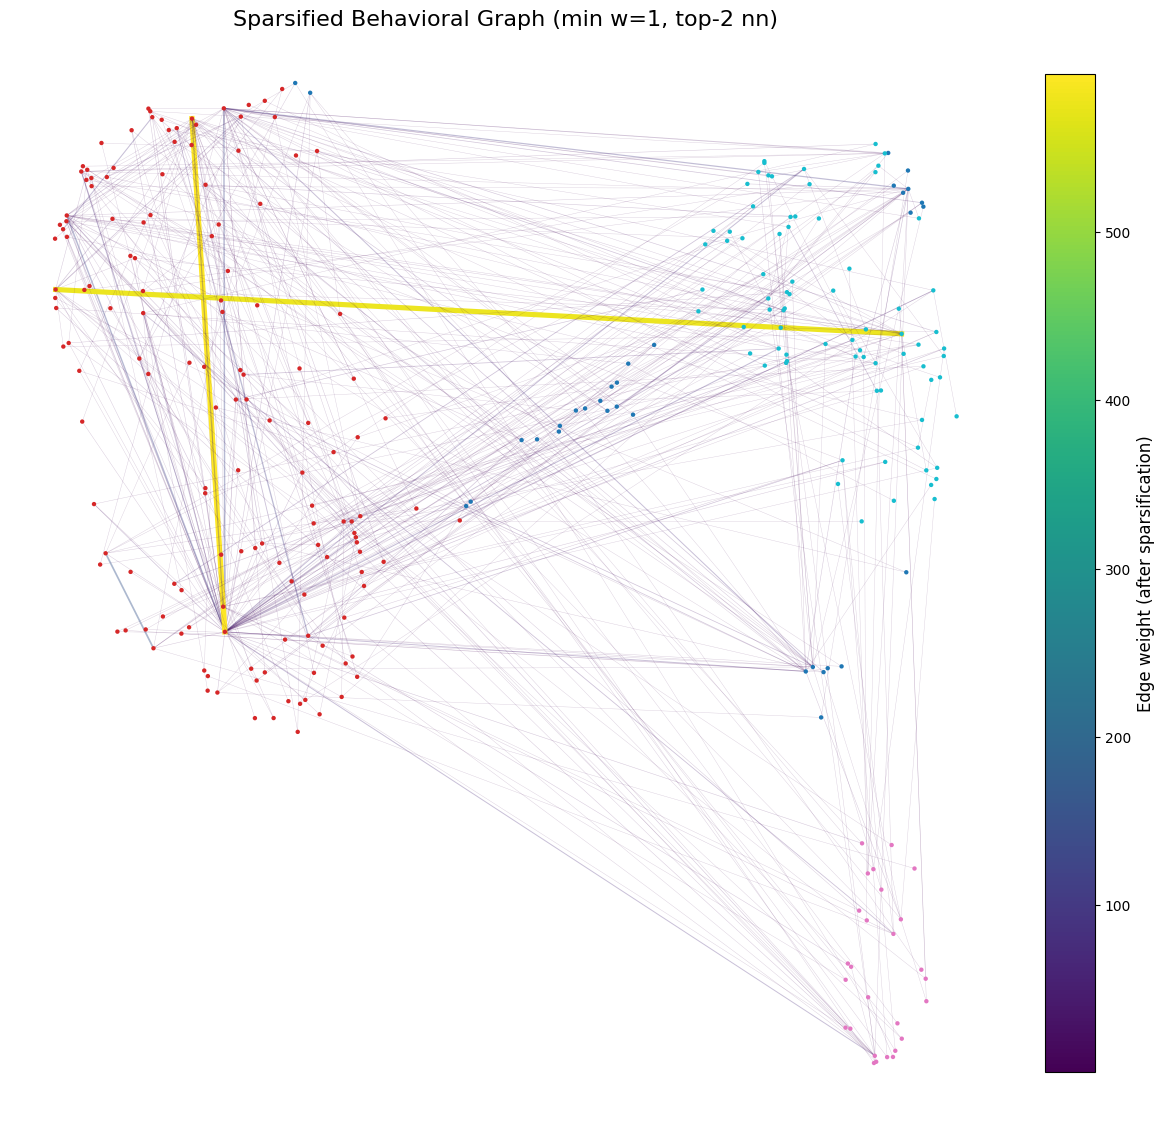

In [78]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ------------------------------
# Parameters (tune these)
# ------------------------------
MIN_W = 1
SPARSIFY_K = 2
MAX_EDGES_PLOT = 40_000
CMAP = plt.cm.viridis    # <--- Wider, smoother gradient!
# ------------------------------

# Load data
edges = pd.read_parquet(BEHAV_FILE)
umap_df = pd.read_parquet(UMAP_FILE)

print("Edge columns:", edges.columns.tolist())

# ------------------------------
# STEP 1: Prune weak edges
# ------------------------------
edges = edges[edges["w"] >= MIN_W].copy()
print(f"[INFO] After pruning (w ≥ {MIN_W}): {len(edges)} edges")

# ------------------------------
# STEP 2: Build weighted graph
# ------------------------------
G = nx.from_pandas_edgelist(
    edges, "a", "b", edge_attr="w", create_using=nx.Graph()
)
print(f"[INFO] Graph nodes: {len(G.nodes())}, edges: {len(G.edges())}")

# ------------------------------
# STEP 3: Sparsify by keeping top-K strongest neighbors
# ------------------------------
kept_edges = set()
absorbed_weight = defaultdict(float)

for u in G.nodes():
    nbrs = [(v, G[u][v]["w"]) for v in G[u]]
    nbrs.sort(key=lambda x: -x[1])  # strongest first
    keep = nbrs[:SPARSIFY_K]

    for v, w in keep:
        a, b = sorted([u, v])
        kept_edges.add((a, b))

    # absorb weaker edges into the strongest
    for v, w in nbrs[SPARSIFY_K:]:
        if keep:
            strong_v, _ = keep[0]
            a, b = sorted([u, strong_v])
            absorbed_weight[(a, b)] += w

# Build sparse graph
SG = nx.Graph()
for (a, b) in kept_edges:
    base = G[a][b]["w"]
    extra = absorbed_weight[(a, b)]
    SG.add_edge(a, b, w=base + extra)

print(f"[INFO] Sparsified edges: {len(SG.edges())}")

# Limit edges for plotting
if len(SG.edges()) > MAX_EDGES_PLOT:
    import random
    random.seed(42)
    edges_to_plot = random.sample(list(SG.edges(data=True)), MAX_EDGES_PLOT)
else:
    edges_to_plot = list(SG.edges(data=True))

# ------------------------------
# STEP 4: Prepare positions + normalize colors
# ------------------------------
pos = {row.song_id: (row.x, row.y) for _, row in umap_df.iterrows()}
node_colors = umap_df.set_index("song_id")["cluster"].to_dict()
node_color_list = [node_colors.get(n, -1) for n in SG.nodes()]

# Extract weights
ws = np.array([d["w"] for (_, _, d) in edges_to_plot])
wmin, wmax = ws.min(), ws.max()

# Normalize
w_norm = (ws - wmin) / (wmax - wmin + 1e-9)

edge_colors = CMAP(w_norm)
edge_alphas = 0.2 + 0.8 * w_norm
edge_widths = 0.3 + 3.5 * w_norm

# ------------------------------
# STEP 5: Plot with gradient legend
# ------------------------------
fig, ax = plt.subplots(figsize=(14, 14))

# Draw edges one-by-one
for (edge, color, alpha, width) in zip(edges_to_plot, edge_colors, edge_alphas, edge_widths):
    (u, v, d) = edge
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    ax.plot([x1, x2], [y1, y2],
            color=color,
            alpha=alpha,
            linewidth=width)

# Draw nodes
nx.draw_networkx_nodes(
    SG, pos,
    node_size=10,
    node_color=node_color_list,
    cmap="tab10",
    linewidths=0,
    ax=ax
)

# ---- Add continuous gradient legend ----
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=wmin, vmax=wmax))
sm.set_array([])  # Required for matplotlib
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Edge weight (after sparsification)", fontsize=12)

plt.title(f"Sparsified Behavioral Graph (min w={MIN_W}, top-{SPARSIFY_K} nn)",
          fontsize=16)
plt.axis("off")
plt.show()

Nodes: 1000 | Edges (drawn): 4519 | Components: 1 | Largest: 1000


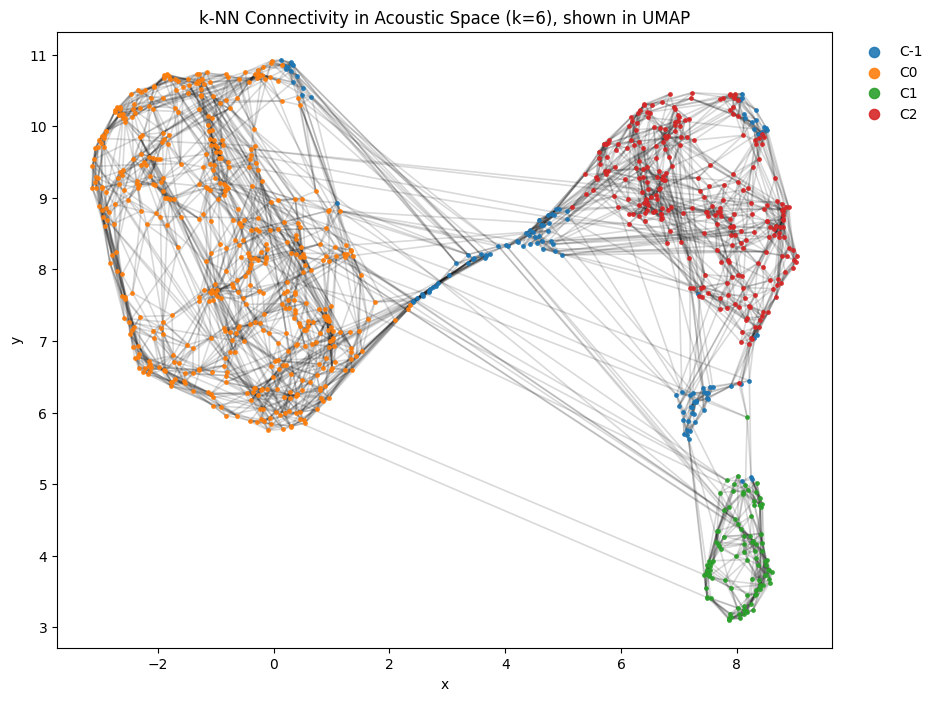

In [79]:
# Connectivity graph overlay (k-NN in acoustic feature space, drawn in UMAP)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import networkx as nxaa
import random

# load UMAP positions + acoustic features and align by song_id
umap_df = pd.read_parquet(UMAP_FILE)[['song_id','x','y','cluster']]
ac = pd.read_parquet(ACOUSTIC_FILE)
NUMERIC_COLS = ['tempo','loudness','time_sig','key','mode','duration','danceability','energy']

dfm = umap_df.merge(ac[['song_id'] + NUMERIC_COLS], on='song_id', how='inner').reset_index(drop=True)
X = dfm[NUMERIC_COLS].to_numpy(dtype=np.float32)
coords = dfm[['x','y']].to_numpy()

# build kNN graph in acoustic space
k = 6  # tweak: 4–12 gives nice structure
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X)
knn_idx = nbrs.kneighbors(return_distance=False)

edges = []
for i, row in enumerate(knn_idx):
    for j in row[1:]:   # skip self
        a, b = (i, j) if i < j else (j, i)
        edges.append((a, b))
edges = list(set(edges))  # dedupe

# optional: subsample edges for speed/clarity
MAX_EDGES = 30_000
if len(edges) > MAX_EDGES:
    random.seed(42)
    edges = random.sample(edges, MAX_EDGES)

# simple connectivity stats
G = nx.Graph()
G.add_nodes_from(range(len(dfm)))
G.add_edges_from(edges)
cc_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Nodes: {len(dfm)} | Edges (drawn): {len(edges)} | Components: {len(cc_sizes)} | Largest: {cc_sizes[0]}")

# draw
plt.figure(figsize=(10,8))
# edges (light)
for a, b in edges:
    xa, ya = coords[a]
    xb, yb = coords[b]
    plt.plot([xa, xb], [ya, yb], lw=1.2, alpha=0.15, color="black", zorder=1)

# nodes (colored by existing cluster)
for c in sorted(dfm['cluster'].unique()):
    pts = dfm[dfm['cluster'] == c]
    plt.scatter(pts['x'], pts['y'], s=6, alpha=0.9, zorder=2, label=f"C{c}")

plt.title(f"k-NN Connectivity in Acoustic Space (k={k}), shown in UMAP")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()


In [80]:
import pandas as pd

umap = pd.read_parquet(UMAP_FILE)
meta = pd.read_parquet("./out_/artist_terms_.parquet")

# ✅ convert all song_id to str (remove b'...' encoding differences)
umap["song_id"] = umap["song_id"].astype(str)
meta["song_id"] = meta["song_id"].astype(str)

merged = umap.merge(meta, on="song_id", how="inner")
print(len(merged), "songs merged")
merged.head()


1001 songs merged


,x,y,cluster,song_id,artist_name,genre
0,-1.912837,10.395324,0,SOLQSBO12A67ADA469,ROBERT MILES Feat. KATHY SLEDGE,
1,8.804930,8.817109,2,SOUXDZB12A8C139108,Sierra Leone Refugee All Stars,
2,5.944291,8.867069,2,SOKIFTM12A58A7AEA9,Free,
3,-2.674500,10.157845,0,SOBWUNT12AB0188A3D,Processor,
4,0.130195,10.929155,-1,SOJSGGD12AB017F941,Marmaduke Duke,


In [ ]:
from collections import Counter

for c, group in merged.groupby("cluster"):
    print("\n===============================")
    print(f"      CLUSTER {c}")
    print("===============================\n")

    counts = Counter(group["artist_name"])
    top_artists = counts.most_common(12)

    print("Representative Artists:")
    for artist, count in top_artists:
        print(f"  {artist:<30} {count}")


      CLUSTER -1

Representative Artists:
  Lily Allen                     2
  Marmaduke Duke                 1
  Veerus & Maxie Devine          1
  Gangster Fun                   1
  Cosmic Gate                    1
  Oscar                          1
  Titus Andronicus               1
  Daturah                        1
  Anthony Braxton                1
  Syd Dale                       1
  Manuel Vallejo                 1
  Angel Anx ft. Amrick Channa    1

      CLUSTER 0

Representative Artists:
  Shrimp Boat                    2
  Steve Vai                      2
  George Hamilton IV             2
  Simon Joyner                   2
  John Fogerty                   2
  ROBERT MILES Feat. KATHY SLEDGE 1
  Processor                      1
  Rufige Kru                     1
  Julie Collings                 1
  Lester Flatt & Earl Scruggs And The Stanley Brothers 1
  LaBelle                        1
  Jody Sticker                   1

      CLUSTER 1

Representative Artists:
  Novadriv

| Cluster | Proposed Label                                  | Main Characteristics                                     |
|--------:|--------------------------------------------------|-----------------------------------------------------------|
| **–1**  | **Eclectic Alternative / Left-Field Pop-Electronic** | Indie pop, experimental rock, trance, avant-jazz, ska      |
| **0**   | **Roots Rock / Folk / Americana**               | Classic rock, folk, alt-country, bluegrass, soul          |
| **1**   | **Alternative Rock / Post-Punk / Heavy Indie**  | Stoner rock, thrash-punk, shoegaze, horror-punk, new wave |
| **2**   | **Rock–Metal + Global / Organic Instrumental**  | Metal, hard rock, African folk, orchestral classical      |

In [26]:
import pandas as pd

# Load behavioral edges
edges = pd.read_parquet(BEHAV_FILE)

print("Columns:", edges.columns.tolist())
print()

# --- 1. Summary statistics ---
print("=== Weight Summary ===")
print(edges["w"].describe())
print()

# --- 2. First few rows ---
print("=== Sample Rows ===")
print(edges.head(20))
print()

# --- 3. Unique weights (may be large; limit output) ---
unique_ws = sorted(edges["w"].unique())
print(f"Unique weights (showing up to 50): {unique_ws[:50]}")
print(f"Total unique weights: {len(unique_ws)}")
print()

# --- 4. Check if any edge has w > 1 ---
print("Any w > 1 ?", (edges["w"] > 1).any())
print("Max weight:", edges["w"].max())
print("Min weight:", edges["w"].min())

Columns: ['a', 'b', 'w']

=== Weight Summary ===
count    365.000000
mean       4.939726
std       19.719229
min        2.000000
25%        2.000000
50%        2.000000
75%        4.000000
max      369.000000
Name: w, dtype: float64

=== Sample Rows ===
                     a                   b    w
0   SOHXNUR12A8C13C80A  SOZVBXH12A67020948    5
1   SODQPTQ12AF72A64BC  SOOLJUA12AC468D252    2
2   SOMTDRQ12A8C13CA7C  SOTGQSF12A58A7B897    5
3   SOMTDRQ12A8C13CA7C  SOQKUUT12A8C139177    4
4   SOEKKIV12A6701D247  SOMTDRQ12A8C13CA7C    3
5   SOCZCBZ12A8C131B67  SOMTDRQ12A8C13CA7C    2
6   SOCZCBZ12A8C131B67  SOWYYSZ12A8C134523   19
7   SOASNQV12A8AE48819  SOMTDRQ12A8C13CA7C    2
8   SOCGMXY12A6701E069  SOMTDRQ12A8C13CA7C    6
9   SOKIKKJ12A8C140397  SOMTDRQ12A8C13CA7C    3
10  SOMJSGV12AC3DF48B7  SOMTDRQ12A8C13CA7C    3
11  SOMTDRQ12A8C13CA7C  SOPNAYR12A6D4FBE22    2
12  SOFSVBU12AB01847D6  SOMTDRQ12A8C13CA7C    2
13  SOIULVR12A6D4F75A5  SOMTDRQ12A8C13CA7C    2
14  SOCGMXY12A6701E069  SO

In [29]:
import pandas as pd

edges = pd.read_parquet(BEHAV_FILE)

print("Number of edges:", len(edges))
print(edges.head())

# basic stats
print("\n=== WEIGHT SUMMARY ===")
print(edges['w'].describe())

# unique weights
unique_w = edges['w'].unique()
print("\nNumber of unique weights:", len(unique_w))
print("First 20 unique weights:", unique_w[:20])

Number of edges: 365
                    a                   b  w
0  SOHXNUR12A8C13C80A  SOZVBXH12A67020948  5
1  SODQPTQ12AF72A64BC  SOOLJUA12AC468D252  2
2  SOMTDRQ12A8C13CA7C  SOTGQSF12A58A7B897  5
3  SOMTDRQ12A8C13CA7C  SOQKUUT12A8C139177  4
4  SOEKKIV12A6701D247  SOMTDRQ12A8C13CA7C  3

=== WEIGHT SUMMARY ===
count    365.000000
mean       4.939726
std       19.719229
min        2.000000
25%        2.000000
50%        2.000000
75%        4.000000
max      369.000000
Name: w, dtype: float64

Number of unique weights: 20
First 20 unique weights: [  5   2   4   3  19   6 369  17   7  65  12  18   9  16  11   8  25  15
  36  10]


In [50]:
w_min = edges['w'].min()
w_max = edges['w'].max()
print("MIN weight:", w_min)
print("MAX weight:", w_max)

MIN weight: 1
MAX weight: 369


In [51]:
# What distances would be used?
distances = 1.0 / edges['w']

print("\n=== BEHAVIORAL DISTANCE SUMMARY ===")
print(distances.describe())

print("Unique distances (first 20):", distances.unique()[:20])


=== BEHAVIORAL DISTANCE SUMMARY ===
count    1429.000000
mean        0.839272
std         0.284412
min         0.002710
25%         0.500000
50%         1.000000
75%         1.000000
max         1.000000
Name: w, dtype: float64
Unique distances (first 20): [1.         0.2        0.5        0.25       0.33333333 0.16666667
 0.05882353 0.14285714 0.05263158 0.00271003 0.08333333 0.01538462
 0.04       0.11111111 0.0625     0.125      0.05555556 0.09090909
 0.06666667 0.02777778]


In [52]:
import numpy as np

print("\n=== CHECK D_be MATRIX ===")
print("Shape:", D_be.shape)

print("Min:", np.min(D_be))
print("Max:", np.max(D_be))

vals = np.unique(D_be)
print("Unique distances (first 50):", vals[:50])


=== CHECK D_be MATRIX ===
Shape: (1000, 1000)
Min: 0.0
Max: 1.0
Unique distances (first 50): [0. 1.]


In [53]:
print(D_be[:10, :10])

[[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]


In [46]:
print("Behavioral sub_edges:", len(sub_edges))
print(sub_edges[:10])

Behavioral sub_edges: 0
[]


In [83]:
import subprocess

output = subprocess.check_output(["wc", "-l", "train_triplets.txt"])
print(output.decode())

 48373586 train_triplets.txt

